In [1]:
!pip install gymnasium[box2d] stable-baselines3[extra] matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 14.4 MB/s eta 0:00:00


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from stable_baselines3.common.results_plotter import load_results, ts2xy

# create environment
def make_env():
    env = gym.make("CarRacing-v3")
    env = Monitor(env, "./logs")  # logs episode rewards
    return env

env = DummyVecEnv([make_env])

# stack frames
env = VecFrameStack(env, n_stack=4)

# create PPO model
model = PPO(
    "CnnPolicy",
    env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    tensorboard_log="./ppo_tensorboard/"
)

# train
model.learn(total_timesteps=150_000)

# save model
model.save("ppo_carracing_v3")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tz

Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to ./ppo_tensorboard/PPO_1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -58.4    |
| time/              |          |
|    fps             | 79       |
|    iterations      | 1        |
|    time_elapsed    | 25       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -56.9       |
| time/                   |             |
|    fps                  | 78          |
|    iterations           | 2           |
|    time_elapsed         | 52          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.005274647 |
|    clip_fraction        | 0.0502      |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.26       |
|    explained_variance   | -0.00441    |
|    learning_rate        | 0.

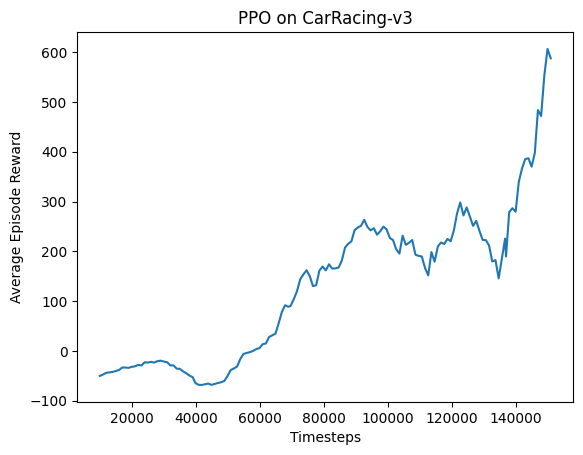

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# load training results
x, y = ts2xy(load_results("."), "timesteps")

# smooth the curve a bit
def moving_average(values, window=10):
    return np.convolve(values, np.ones(window)/window, mode='valid')

y_smooth = moving_average(y)

# plot
plt.plot(x[len(x)-len(y_smooth):], y_smooth)
plt.xlabel("Timesteps")
plt.ylabel("Average Episode Reward")
plt.title("PPO on CarRacing-v3")
plt.show()

In [8]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from gymnasium.wrappers import RecordVideo

# load model
model = PPO.load("ppo_carracing_v3")

# create env properly
def make_env():
    env = gym.make("CarRacing-v3", render_mode="rgb_array")
    env = RecordVideo(env, video_folder="./videos", episode_trigger=lambda x: True)
    return env

# THEN vectorize
env = DummyVecEnv([make_env])
env = VecFrameStack(env, n_stack=4)

obs = env.reset()

for _ in range(2000):
    action, _ = model.predict(obs, deterministic=True)
    obs, rewards, dones, infos = env.step(action)

    if dones[0]:
        break

env.close()

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
